In [1]:
import os
import json
import random
import itertools
import math

import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from matplotlib import colormaps
from IPython.display import display, HTML

from models import get_model
from data import get_dataset

# plt.rcParams["font.size"] = 24
# plt.rcParams["font.family"] = "cmr10"

os.environ["TOKENIZERS_PARALLELISM"] = "true"


[nltk_data] Downloading package punkt_tab to /home/xia/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
device = "cuda:7"
model_dir = "/home/xia/claim-xai/configs/hateful-memes/base"
model_config = json.load( open(os.path.join(model_dir, "config.json"), "r") )
model_metadata = json.load( open(os.path.join(model_dir, "masker/_metadata.json"), "r") )

In [3]:
ds_train, ds_val, ds_test, num_classes = get_dataset(
    model_config["dataset_name"], 
    data_dir = "../_datasets", 
    splits = ["train", "validation", "test"],
    **model_config["dataset_args"], 
)


model = get_model(
    model_name = model_config["model_name"],
    checkpoint_path = os.path.join(model_dir, model_metadata["best_checkpoint"]),
    **model_config["model_args"]
).eval().to(device)

Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


---

In [4]:
# os.environ["TOKENIZERS_PARALLELISM"] = "true"
# correct = 0

# with torch.no_grad():
#     for images, labels in tqdm(DataLoader(ds_test, batch_size=32, num_workers=2)):
#         # images = images.to(device)
#         labels = labels.to(device)
        
#         inputs = model.preprocess(images)
#         logits, _ = model(inputs)

#         correct += (torch.argmax(logits, dim=1) == labels).sum()

# print(correct / len(ds_test))

In [5]:
# loss = 0

# with torch.no_grad():
#     for texts, labels in tqdm( DataLoader(ds_test, batch_size=32, num_workers=2) ):
#         inputs = model.preprocess(texts)
#         logits, weights = model(inputs)
#         logits = logits.cpu()

#         for b in range(len(logits)):
#             print(logits[b].shape)
#             loss += F.cross_entropy(logits[b], labels[b]).item()

# print(loss / len(ds_test))

pred=0 label=1


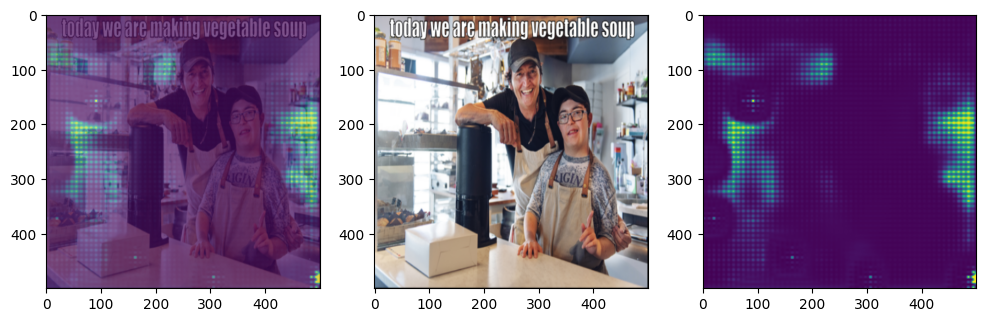

In [12]:
image, text, label = ds_test[30]

with torch.no_grad():
    image_inputs, text_inputs = model.preprocess([image], [text])
    logits, text_weights, image_weights = model(image_inputs, text_inputs)

tokens = text_inputs["input_ids"].cpu().squeeze(0)
text_weights = text_weights[0].cpu().squeeze(1)
image_weights = image_weights[0].cpu()


print(f"pred={torch.argmax(logits).item()} label={label}")


tokens = tokens.tolist()
text_weights = text_weights.tolist()



# plt.hist(weights)
# plt.yscale("log")
# plt.show()



text = []
scores = []
curr_word = []

for t, w in zip(tokens[1:], text_weights[1:]):
    tok = model.text_encoder._model.tokenizer.decode(t)
    if tok == "<pad>": break

    if (len(curr_word) != 0) and (tok[0] == ' '):
        text.append("".join([t for t, w in curr_word]).strip())
        scores.append(sum([w for t, w in curr_word]) / len(curr_word))
        curr_word = []
    curr_word.append((tok, w))
    
if len(curr_word) != 0:
    text.append("".join([t for t, w in curr_word]).strip())
    scores.append(sum([w for t, w in curr_word]) / len(curr_word))



def highlighter(word, score):
    color = colormaps["OrRd"](round((score) * 255))
    color = [round(c*255) for c in color]
    return f"<span style='color: {'white' if score > 0.75 else 'black'}; background-color: rgb({color[0]} {color[1]} {color[2]})'>{word}</span>"

display(HTML(
    ' '.join([('<br>' if t in ["[CONTEXT]", "[QUESTION]", "[OPTION0]", "[OPTION1]", "[OPTION2]", "[OPTION3]"] else '') + highlighter(t, s)
    for t, s in zip(text, scores)])
))


image = image.cpu().permute(1, 2, 0)
image_weights = torchvision.transforms.functional.resize(image_weights.cpu(), image.shape[1:2]).permute(1, 2, 0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.imshow(image_weights, alpha=0.7)
plt.subplot(1, 3, 2)
plt.imshow(image)
plt.subplot(1, 3, 3)
plt.imshow(image_weights)
plt.show()

In [7]:
# for t in text:
#     print(f"{t:<4}", end=" ")

# print()

# for t, w in zip(text, scores):
#     print(f"{w:<{len(t)}.2f}", end=" ")





for t in tokens:
    if model.text_encoder._model.tokenizer.decode(t) == "<pad>": break
    print(f"{model.text_encoder._model.tokenizer.decode(t):<4}", end=" ")

print()

for t, w in zip(tokens, weights):
    dec_tok = model.text_encoder._model.tokenizer.decode(t)
    if dec_tok == "<pad>": break
    print(f"{w:<{len(dec_tok)}.2f}", end=" ")

<s>  A     basketball  player  performing  a    lay -    up    .   </s> 


NameError: name 'weights' is not defined